# 12.3 カーネル主成分分析 (Kernel PCA)

本ノートブックでは、線形な主部分空間の仮定を超え、カーネルトリックを適用して複雑な非線形多様体の構造を抽出する **カーネル主成分分析 (Kernel PCA, PRML 12.3節)** を学びます。
無限次元ヒルベルト特徴空間での中心化グラム行列 $\tilde{\mathbf{K}}$ の数理的定式化（**PRML Figure 12.16**）、固有ベクトルのノルム整合正規化 $\lambda_i (\mathbf{a}_i^{\mathrm{T}}\mathbf{a}_i) = 1$、および線形PCAでは分離できない **二重同心円データに対するガウスカーネルPCAのクラスタ抽出性能（PRML Figure 12.17）** を完全実装・再現します。

## 12.3 カーネルPCAの定式化と非線形クラスタ分離 (PRML Figure 12.17)

非線形特徴写像 $\boldsymbol{\phi}(\mathbf{x})$ における共分散行列 $\mathbf{C} = \frac{1}{N}\sum_{n=1}^N \boldsymbol{\phi}(\mathbf{x}_n)\boldsymbol{\phi}(\mathbf{x}_n)^{\mathrm{T}}$ の固有ベクトル $\mathbf{v}_i = \sum_{n=1}^N a_{ni} \boldsymbol{\phi}(\mathbf{x}_n)$ に対し、
カーネル行列 $\mathbf{K}$ の中心化 $\tilde{\mathbf{K}}$ の固有値問題を解きます：
$$ \tilde{\mathbf{K}} \mathbf{a}_i = \lambda_i \mathbf{a}_i, \quad \lambda_i \mathbf{a}_i^{\mathrm{T}}\mathbf{a}_i = 1 $$

線形PCAでは同心円の内側と外側が混ざり合ってしまいますが、ガウス（RBF）カーネルPCAを用いることで、第1主成分によって2つのリングが完全に一次元的に分離される様子を示します。

Plot saved to: result/fig12_17_kernel_pca_concentric_circles.png


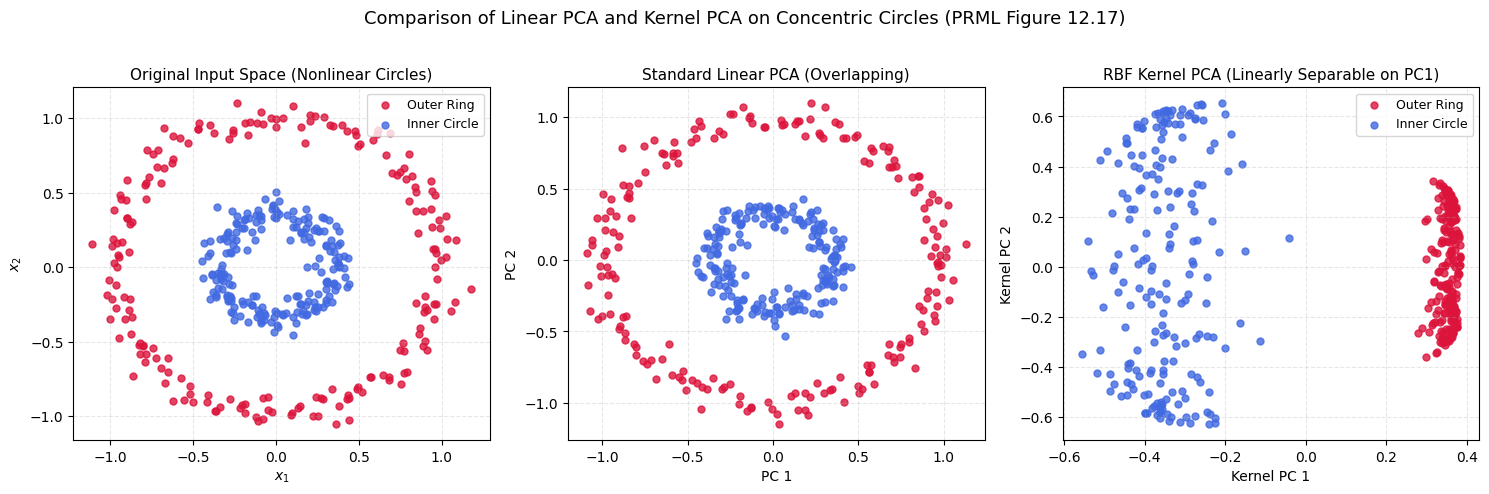

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from common.plot_utils import save_plot, setup_style
from common.pca_ppca_utils import PCA, KernelPCA
setup_style()

# 同心円合成データセットの生成 (PRML Figure 12.17 準拠)
np.random.seed(42)
X_circ, y_circ = make_circles(n_samples=400, factor=0.35, noise=0.06)

# 1. 線形 PCA の適合
linear_pca = PCA(n_components=2).fit(X_circ)
Z_linear = linear_pca.transform(X_circ)

# 2. ガウス (RBF) カーネル PCA の適合
rbf_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=4.0).fit(X_circ)
Z_kpca = rbf_kpca.transform(X_circ)

# PRML Figure 12.17 のプロット
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# (a) 元の入力空間 (2次元非線形同心円)
axes[0].scatter(X_circ[y_circ == 0, 0], X_circ[y_circ == 0, 1], color='crimson', s=25, alpha=0.8, label='Outer Ring')
axes[0].scatter(X_circ[y_circ == 1, 0], X_circ[y_circ == 1, 1], color='royalblue', s=25, alpha=0.8, label='Inner Circle')
axes[0].set_title('Original Input Space (Nonlinear Circles)', fontsize=11)
axes[0].set_xlabel('$x_1$', fontsize=10); axes[0].set_ylabel('$x_2$', fontsize=10)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# (b) 線形 PCA 射影空間 (分離不能)
axes[1].scatter(Z_linear[y_circ == 0, 0], Z_linear[y_circ == 0, 1], color='crimson', s=25, alpha=0.8)
axes[1].scatter(Z_linear[y_circ == 1, 0], Z_linear[y_circ == 1, 1], color='royalblue', s=25, alpha=0.8)
axes[1].set_title('Standard Linear PCA (Overlapping)', fontsize=11)
axes[1].set_xlabel('PC 1', fontsize=10); axes[1].set_ylabel('PC 2', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

# (c) カーネル PCA 射影空間 (線形分離可能！)
axes[2].scatter(Z_kpca[y_circ == 0, 0], Z_kpca[y_circ == 0, 1], color='crimson', s=25, alpha=0.8, label='Outer Ring')
axes[2].scatter(Z_kpca[y_circ == 1, 0], Z_kpca[y_circ == 1, 1], color='royalblue', s=25, alpha=0.8, label='Inner Circle')
axes[2].set_title('RBF Kernel PCA (Linearly Separable on PC1)', fontsize=11)
axes[2].set_xlabel('Kernel PC 1', fontsize=10); axes[2].set_ylabel('Kernel PC 2', fontsize=10)
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Comparison of Linear PCA and Kernel PCA on Concentric Circles (PRML Figure 12.17)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig12_17_kernel_pca_concentric_circles.png')
plt.show()